Dataset Summary:
 - paper:
   Tot. Images: 712
   Sizes: [200 300]
   Mean Class Brightness: 116.13810074257957
   Std Class Brightness: 10.383552042815877


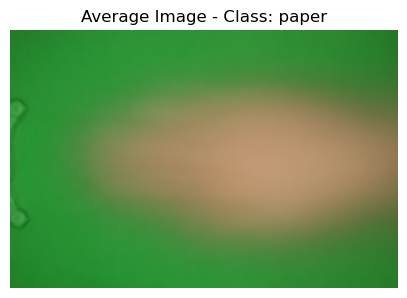

 - rock:
   Tot. Images: 726
   Sizes: [200 300]
   Mean Class Brightness: 113.87459168498621
   Std Class Brightness: 9.705818166786603


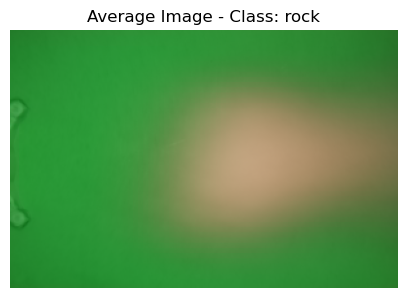

 - scissors:
   Tot. Images: 750
   Sizes: [200 300]
   Mean Class Brightness: 113.18805738682222
   Std Class Brightness: 10.090162478846906


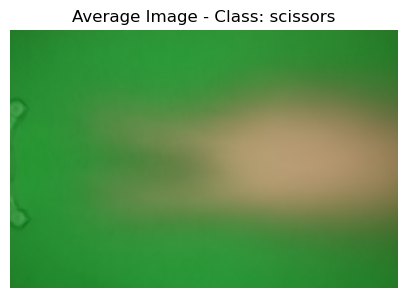

None


In [ ]:
import os
from PIL import Image
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

def explore_dataset(data_dir):
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

    avg_img = np.zeros((200,300, 3), dtype=np.float64)

    print("Dataset Summary:")
    for cls in classes:
        print(f" - {cls}:")
        cls_dir = os.path.join(data_dir, cls)
        images = os.listdir(cls_dir)
        num_images = 0
        sizes = []
        brightness_values = []
        accumulated_array = np.empty_like(avg_img)


        for i in images:
            img_path = os.path.join(cls_dir, i)
            with Image.open(img_path) as img:
                if img.mode != "RGB":
                    img = img.convert("RGB")
                sizes.append(img.size)
                img_array = np.array(img, dtype=np.float64)
                accumulated_array += img_array

                # Formula di luma CCIR 601
                brightness = np.mean(0.299 * img_array[:,:,0] + 0.587 * img_array[:,:,1] + 0.114 * img_array[:,:,2])
                brightness_values.append(brightness)
            num_images += 1 
        
        avg_img = (accumulated_array / num_images) / 255.0
        class_mean_brightness = np.mean(brightness_values)
        class_std_brightness = np.std(brightness_values)
        
        print(f"   Tot. Images: {num_images}")
        print(f"   Sizes: {np.unique(sizes)}")
        print(f"   Mean Class Brightness: {class_mean_brightness}")
        print(f"   Std Class Brightness: {class_std_brightness}")
        
        plt.figure(figsize=(5,5))
        plt.imshow(avg_img)
        plt.title(f"Average Image - Class: {cls}")
        plt.axis("off")
        plt.show()
    


explore_dataset("../data/raw")
